#/**************************************
#* NOMBRE: #Cesar Antonio#
#* PRIMER APELLIDO: #Navas#
#* SEGUNDO APELLIDO: #Calatrava#
#* Alias: #Cancalatrava#
#* EMAIL: #cancalatrava@gmail.com#
#***************************************/

In [1]:
#!pip uninstall -y pandas numpy
#!pip install pandas numpy
#!pip install openpyxl 
#!pip install xgboost
# Importamos las librerías necesarias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
# cargamos librerias de nuestros modelos de entrenamiento
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import PolynomialFeatures
import plotly.graph_objects as go


# Cargamos el dataset
df = pd.read_excel(r'data/20260427 train_competicion.xlsx')


Importamos el datadset para observar el estado de los datos

In [2]:
# Exploramos el dataset
print("Head dataset")
print(df.head(20))
print("\ninfo dataset")
print(df.info())
print("\ndescripcion dataset")
print(df.describe())
#hay duplicados?
print(df.duplicated().sum())
variable_objetivo='deseada'

Head dataset
        V0        V1        V2          V3        V4     V5     V6   V7   V8  \
0    98.61  4.068343       NaN    8.665653 -1.092046  2.891  1.442  NaN  0.0   
1    20.31  3.376529  0.000000   -0.020346  0.717691  1.401  2.073  1.0  1.0   
2    45.82  3.946366  0.000000    6.719171  0.433881  2.048    NaN  1.0  0.0   
3    91.49  4.773866  2.236068   -0.035611  0.693325  1.868  1.621  5.0  0.0   
4     0.00  0.000000       NaN   99.510312 -1.081747  2.018  0.461  0.0  NaN   
5     0.00  0.000000  0.000000   11.466731  0.616436  1.800  0.917  0.0  0.0   
6     0.00       NaN  0.000000   25.464081 -0.777390  1.989  1.063  0.0  0.0   
7    12.53  2.484907  0.000000    3.602686  1.058744  2.274  1.026  NaN  0.0   
8    81.95       NaN       NaN    2.504375 -1.935766  3.325    NaN  NaN  0.0   
9    20.23  3.776959  1.000000    0.512000 -0.324832  1.401  1.698  0.0  0.0   
10   57.53  4.714132  1.414214   36.264691 -0.640904  3.267    NaN  0.0  NaN   
11   36.26  4.113232  0.000

📊 Variable: V0
✅ ¡Limpia! No tiene valores NaN.
----------------------------------------


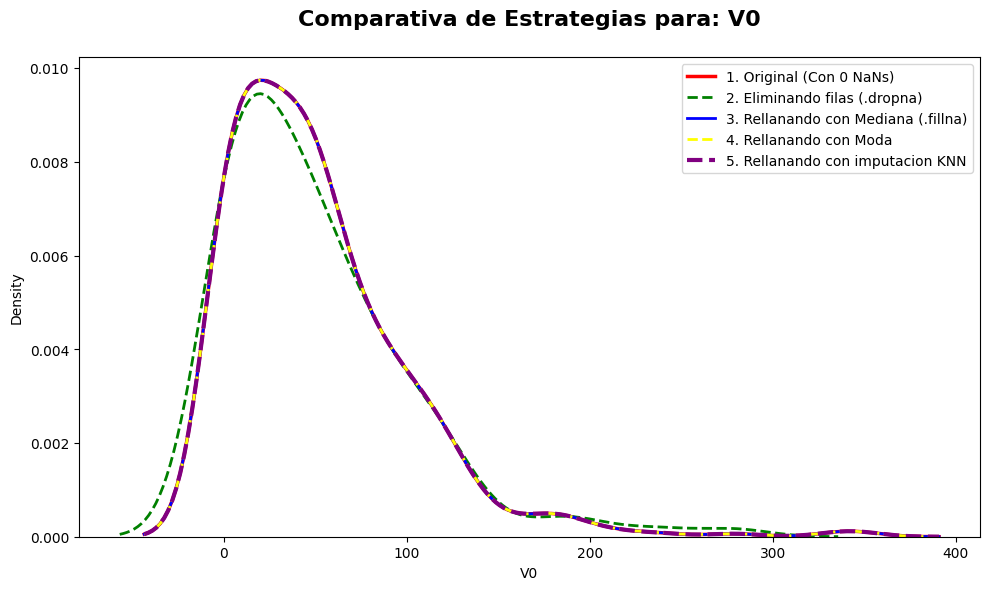

📊 Variable: V1
❌ Tiene 71 valores NaN (16.28% del total).
----------------------------------------


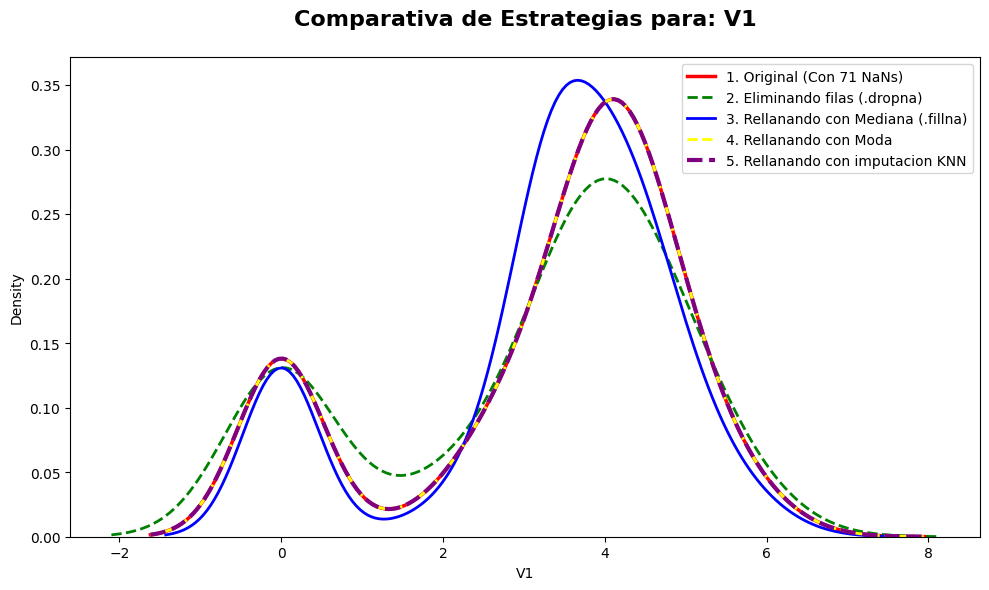

📊 Variable: V2
❌ Tiene 63 valores NaN (14.45% del total).
----------------------------------------


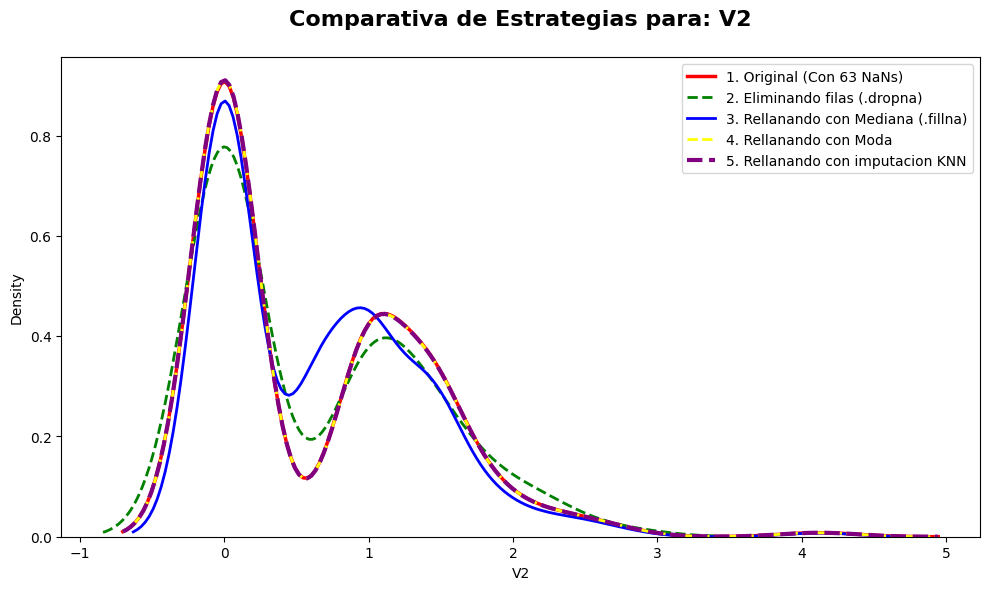

📊 Variable: V3
❌ Tiene 68 valores NaN (15.60% del total).
----------------------------------------


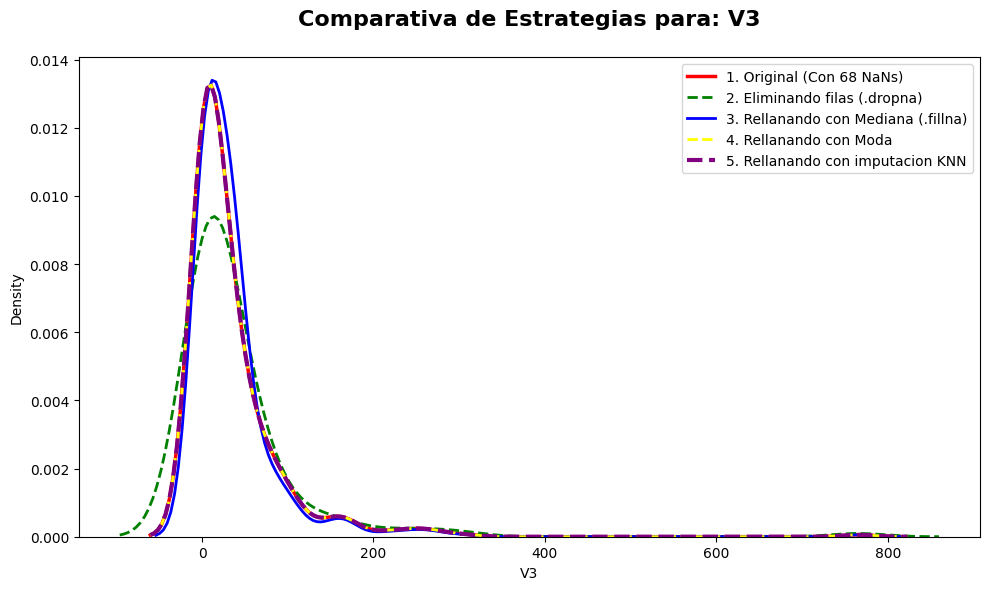

📊 Variable: V4
✅ ¡Limpia! No tiene valores NaN.
----------------------------------------


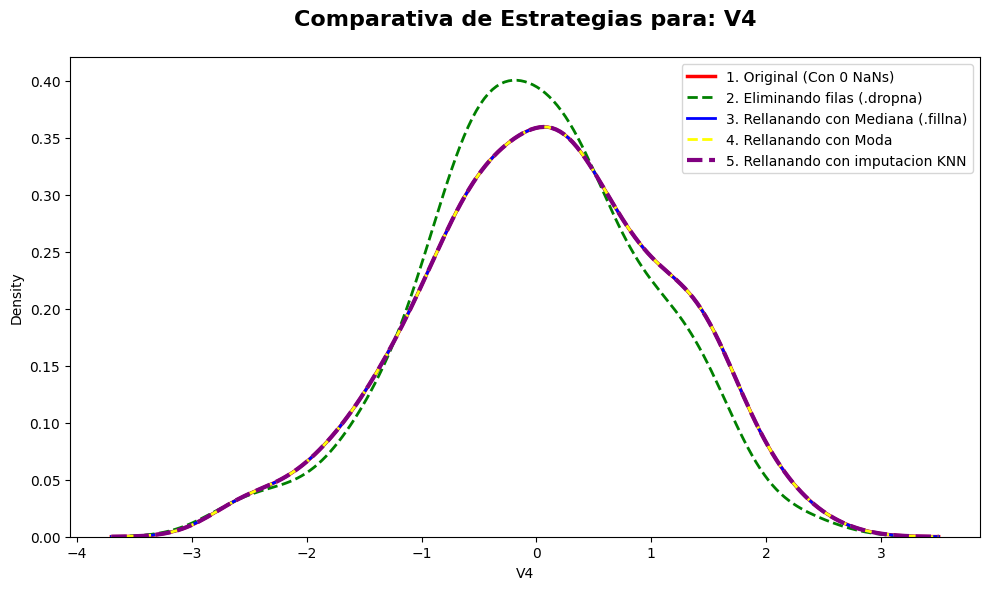

📊 Variable: V5
❌ Tiene 63 valores NaN (14.45% del total).
----------------------------------------


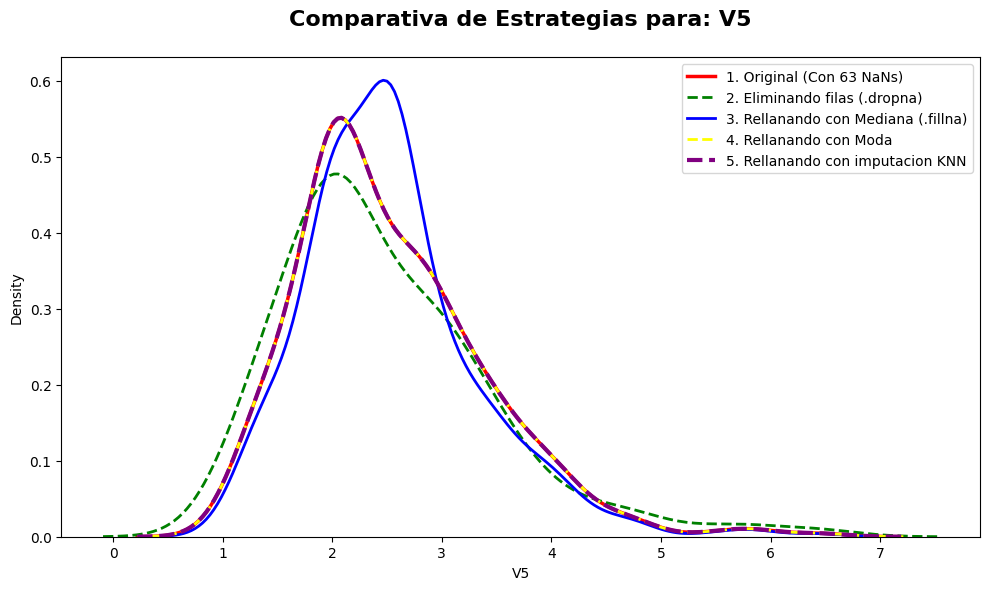

📊 Variable: V6
❌ Tiene 70 valores NaN (16.06% del total).
----------------------------------------


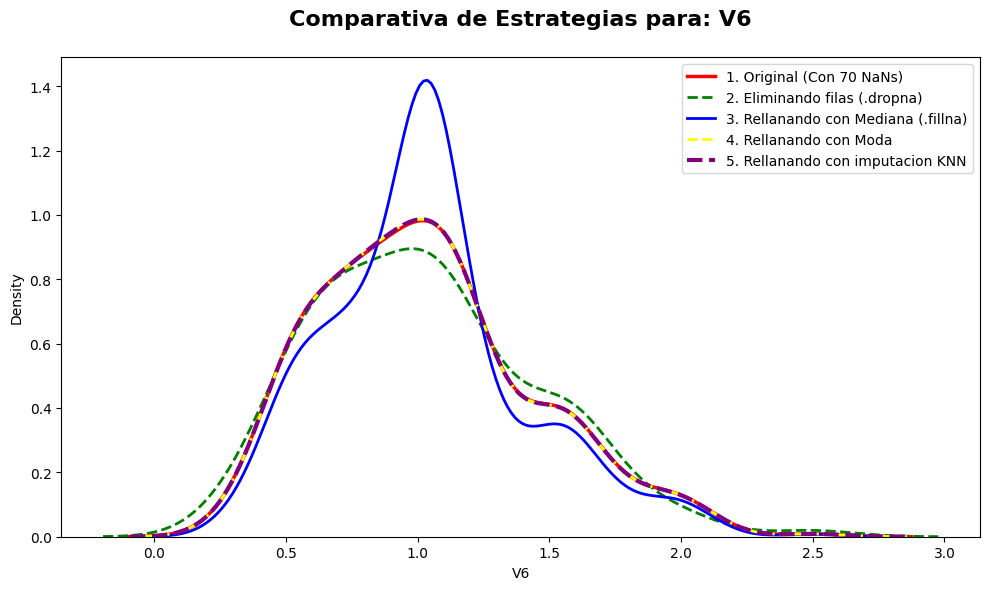

📊 Variable: V7
❌ Tiene 60 valores NaN (13.76% del total).
----------------------------------------


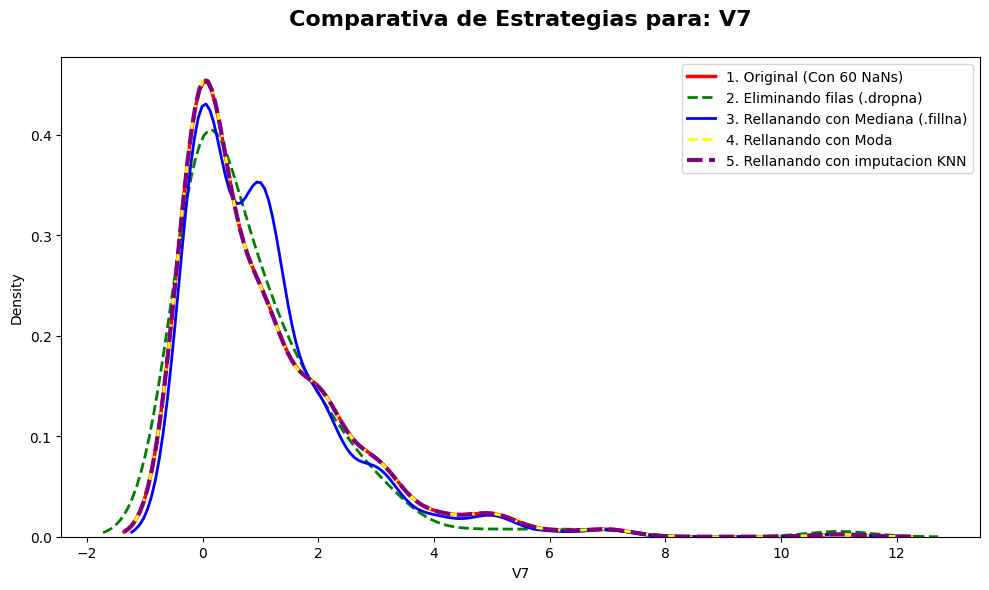

📊 Variable: V8
❌ Tiene 68 valores NaN (15.60% del total).
----------------------------------------


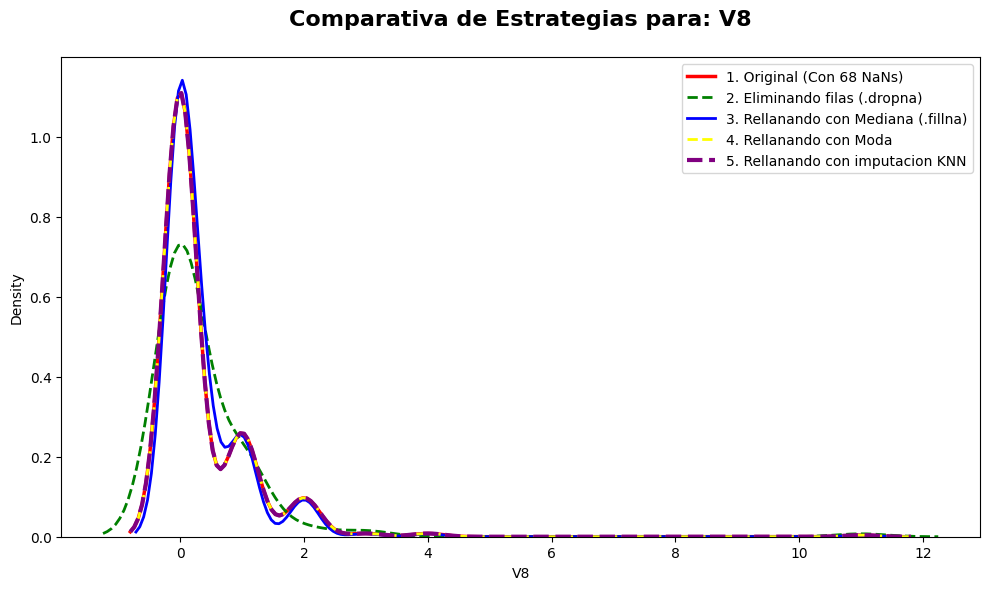

📊 Variable: V9
✅ ¡Limpia! No tiene valores NaN.
----------------------------------------


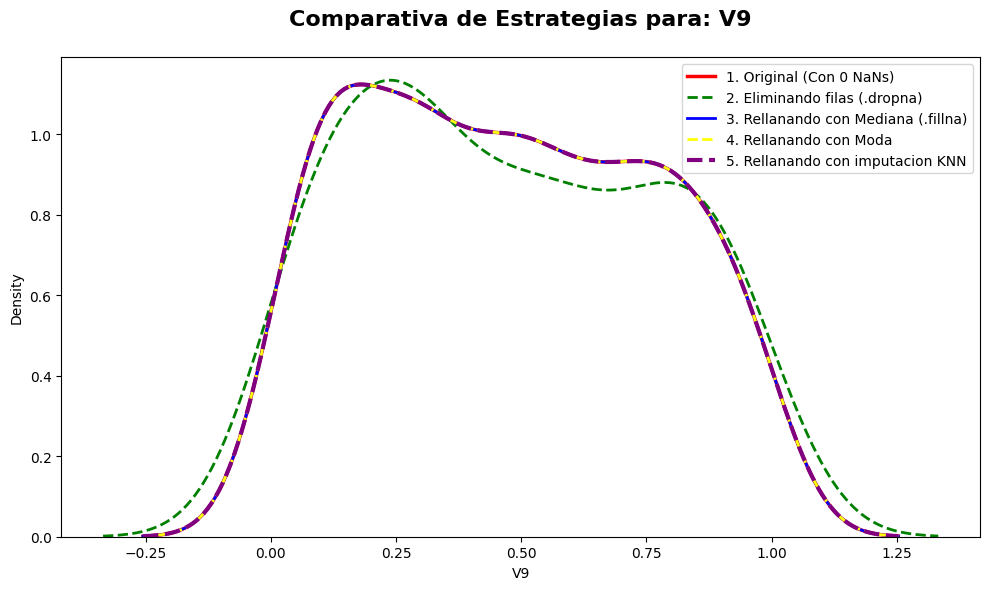

📊 Variable: deseada
✅ ¡Limpia! No tiene valores NaN.
----------------------------------------


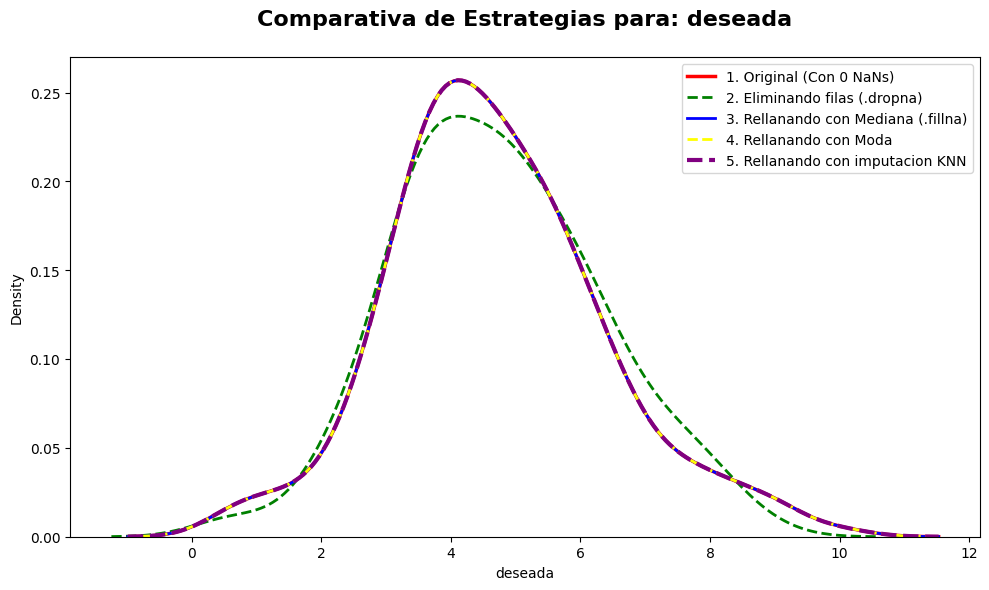

In [8]:
#analisemos mis variables y comprobamos que deberiamos hacer con los valores nulos.
tnulos = 0
total_filas = len(df)
# Estrategias para manejar los valores nulos
df_sin_nulos = df.dropna()
df_fill_media = df.fillna(df.mean())
df_fill_moda = df.fillna(df.mode())

# Imputación con KNN
variable_objetivo = "deseada"
df_Knn = df.drop(columns=[variable_objetivo]).copy()
imputer = KNNImputer(n_neighbors=5)
columnas = df_Knn.select_dtypes(include=["number"]).columns
df_Knn[columnas] = imputer.fit_transform(df_Knn[columnas])


columns = df.select_dtypes(include=["number"]).columns
for col in columns:
    nulos = df[col].isna().sum()
    porcentaje_nulos = (nulos / total_filas) * 100
    col_original = df[col]
    col_nonull = df_sin_nulos[col]
    col_fill_media = df_fill_media[col]
    col_fill_moda = df_fill_moda[col]
    # Imprimir el reporte en consola
    print(f"📊 Variable: {col}")
    if nulos > 0:
        print(
            f"❌ Tiene {nulos} valores NaN ({porcentaje_nulos:.2f}% del total)."
        )
    else:
        print("✅ ¡Limpia! No tiene valores NaN.")
    print("-" * 40)

    plt.figure(figsize=(10, 6))
    sns.kdeplot(
            col_original,
            color="red",
            linewidth=2.5,
            label=f"1. Original (Con {nulos} NaNs)"
        )
    
    sns.kdeplot(
            col_nonull,
            color="green",
            linewidth=2,
            linestyle="--",
            label="2. Eliminando filas (.dropna)",
        )
    
    sns.kdeplot(
            col_fill_media,
            color="blue",
            linewidth=2,
            label="3. Rellanando con Mediana (.fillna)"
        )
        
    sns.kdeplot(
            col_fill_moda,
            color="yellow",
            linestyle="--",
            linewidth=2,
            label="4. Rellanando con Moda"
        )
    
    sns.kdeplot(
            col_fill_moda,
            color="purple",
            linestyle="--",
            linewidth=3,
            label="5. Rellanando con imputacion KNN"
        )
    
    plt.title(
            f"Comparativa de Estrategias para: {col}",
            fontsize=16,
            fontweight="bold",
            y=1.05
        )
    plt.tight_layout()
    plt.legend()
    plt.show()

Resumen de estrategias: las mejores tecnicas serian las de rellenar con moda(menos costosa en calculo). y rellenar con vecinos (mas popular)
empezaremos nuestro modelo predictivo.

In [4]:
#preparamos los datos.


X = df_Knn
Y = df[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#entrenamos el modelo de regresion Random Forest Regressor
modelo = RandomForestRegressor(
    n_estimators=250, 
    # max_depth=None,
    # min_samples_split=5,
    # min_samples_leaf=5,
    # max_features=1.0,
    random_state=42)
modelo.fit(X_train, y_train)

print("pre - Modelo de regresión entrenado con éxito!")

pre - Modelo de regresión entrenado con éxito!


In [5]:
#EVALUACION DE LAS PREDICCIONES 

y_pred = modelo.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("📈 METRICAS DE RENDIMIENTO:")
print(f"🔹 R² (Coeficiente de Determinacion): {r2:.4f}")
print(f"🔹 MAE (Error Absoluto Medio): {mae:.2f}")
print(f"🔹 RMSE (Raiz del Error Cuadratico Medio): {rmse:.2f}")
print("-" * 42)

📈 METRICAS DE RENDIMIENTO:
🔹 R² (Coeficiente de Determinacion): 0.5432
🔹 MAE (Error Absoluto Medio): 0.86
🔹 RMSE (Raiz del Error Cuadratico Medio): 1.19
------------------------------------------


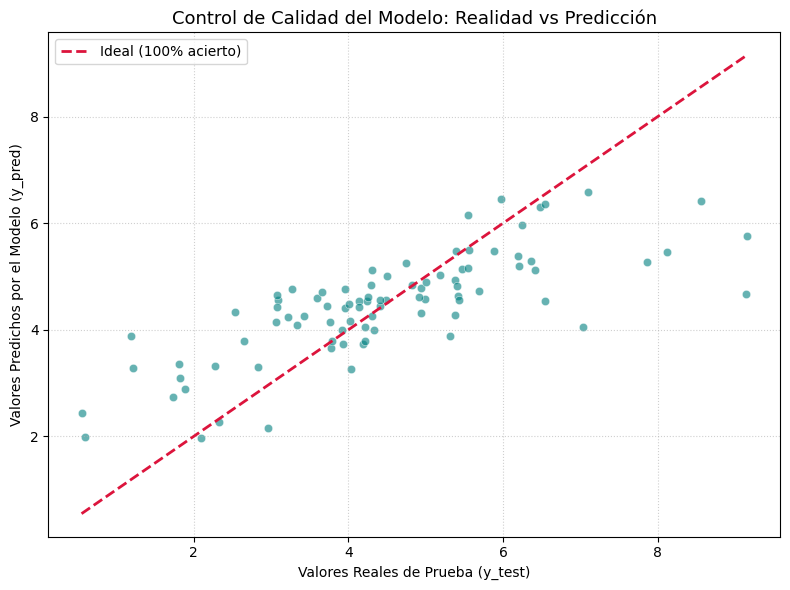

In [6]:
#Graficamos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="teal")

limites = [y_test.min(), y_test.max()]
plt.plot(
    limites,
    limites,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Ideal (100% acierto)",
)

plt.title("Control de Calidad del Modelo: Realidad vs Predicción", fontsize=13)
plt.xlabel("Valores Reales de Prueba (y_test)")
plt.ylabel("Valores Predichos por el Modelo (y_pred)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

A QUE VARIABLES LE HACE CASO EL MODELO
--------------------------------------------------
1. Variable 'V3': 0.2783
2. Variable 'V5': 0.1832
3. Variable 'V6': 0.1346
4. Variable 'V0': 0.1089
5. Variable 'V9': 0.0670
6. Variable 'V2': 0.0631
7. Variable 'V4': 0.0615
8. Variable 'V1': 0.0539
9. Variable 'V7': 0.0299
10. Variable 'V8': 0.0195
--------------------------------------------------


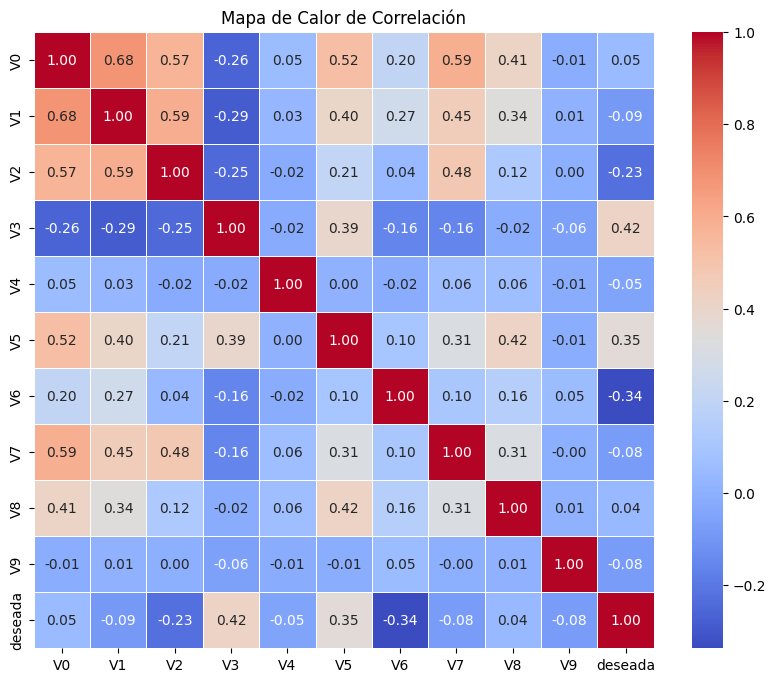

In [7]:
# re-evaluacion del modelo.
importancias = modelo.feature_importances_
indices = np.argsort(importancias)[::-1]

print("A QUE VARIABLES LE HACE CASO EL MODELO")
print("-" * 50)
for f in range(X_train.shape[1]):
    print(
        f"{f + 1}. Variable '{X_train.columns[indices[f]]}': {importancias[indices[f]]:.4f}"
    )
print("-" * 50)

# 2. Mapa de calor de correlación (Para ver si hay variables "clonadas")
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Mapa de Calor de Correlación")
plt.show()